<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# SAOP09 - Data Science For Business
## Prof. Eduardo Pécora

# Regressão Linear Múltipla - $R^2$
Tempo estimado: **30** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Entender o impacto do $R^2$ e as razões pelas quais ele não é um bom estimador de eficiência do método

## Bibliotecas

In [9]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd

# Importando numpy para criar, manipular e operar em arrays multidimensionais, bem como para realizar operações matemáticas avançadas.
import numpy as np

# Importando a biblioteca math que fornece funções matemáticas básicas
import math

# importando as bibliotecas do matplotlib para gerar gráficos
import matplotlib as mpl
import matplotlib.pyplot as plt

# Importando biblioteca do seaborn para gerar gráficos mais atraentes e informativos
import seaborn as sns

# Importando a classe LinearRegression do sklearn
# Essa classe implementa uma versão da regressão linear simples ou múltipla
# Usado para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

# Usado para exibir os gráficos gerados pela biblioteca Matplotlib diretamente no notebook, sem precisar abrir uma janela externa.
%matplotlib inline

## Obtendo dados

In [10]:
# Caminho do arquivo csv
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/MeuAutoLimpo.csv"

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho)

In [11]:
df.dtypes

,0
symboling,int64
normalized-losses,int64
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


## Regressão Linear Múltipla

### Revisando

$$
    X_k : Variáveis \ independentes \\
    Y : Variável \ dependente
$$

**Função Linear**
$$
    Yhat = \alpha + \beta_1  X_1 \ + \ \beta_2  X_2 \ + \ ... + \ \beta_k  X_k
$$

* a : se refere ao intercepto da regressão linear, ou seja, o valor de Y quando todos X são 0.
* b1, b2, bk : são os coeficientes de regressão, que representam a influência de cada variável X independente em Yhat

### Implementação

<p>Vamos desenvolver um modelo utilizando as seguintes variáveis como preditoras.</p>
<ul>
    <li>Horsepower</li>
    <li>Highway-mpg</li>
</ul>


In [12]:
# Criando um objeto para regressão
lm = LinearRegression()
lm

LinearRegression()

In [13]:
# Ajustando o novo dataframe
#df=df[['price','engine-size', 'curb-weight']]
df_linear_multipla = df.drop(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
                             'drive-wheels', 'engine-location','engine-type', 'num-of-cylinders', 'fuel-system',], axis=1)

# Criando as novas variáveis
X = df_linear_multipla.drop(["price"], axis = 1)
Y = df_linear_multipla['price']

# Carregando o modelo
lm.fit(X, Y)

# Exibindo o R^2
R2=lm.score(X,Y)

print("SCORE: %.4f" % R2)

SCORE: 0.8504


## O impacto do $R^2$

Text(0, 0.5, 'R2')

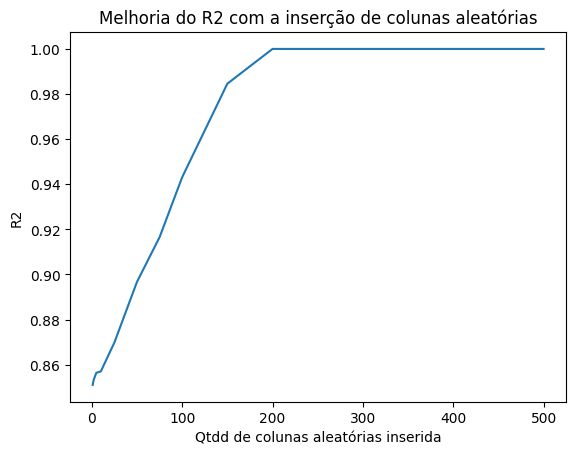

In [14]:
col_random = [1,2,5,10,25,50,75,100,150,200,300,500]
# Adicionando x colunas aleatórias no DF original
r2_list = []
for c in col_random:
  # Criando todas as colunas aleatórias de uma vez (evita fragmentar o DataFrame)
  colunas_aleatorias = pd.DataFrame(
      np.random.randint(1, 100, size=(len(df_linear_multipla), c)),
      columns=[f'Random_{i+1}' for i in range(c)],
      index=df_linear_multipla.index
  )
  df_new = pd.concat([df_linear_multipla, colunas_aleatorias], axis=1)

  # Criando as novas variáveis (nomes locais, para não sobrescrever X, Y, lm do modelo oficial)
  X_temp = df_new.drop(["price"], axis = 1)
  Y_temp = df_new['price']

  # Carregando um modelo à parte, só para esta demonstração
  lm_demo = LinearRegression()
  lm_demo.fit(X_temp, Y_temp)

  # Exibindo o R^2
  R2_demo = lm_demo.score(X_temp, Y_temp)
  r2_list.append(R2_demo)

sns.lineplot(x=col_random,y=r2_list)
plt.title("Melhoria do R2 com a inserção de colunas aleatórias")
plt.xlabel("Qtdd de colunas aleatórias inserida")
plt.ylabel("R2")

## O que isso significa para as previsões?

O gráfico acima mostra o $R^2$ subindo conforme adicionamos colunas aleatórias. Mas será que isso também aparece nas previsões e nos resíduos do modelo? Vamos comparar diretamente o modelo honesto (13 variáveis reais) com uma versão "inflada" dele, usando 150 colunas aleatórias — o mesmo nível extremo do gráfico anterior.

In [15]:
# Recriando o modelo inflado com 150 colunas aleatórias (mesmo procedimento do gráfico anterior)
c = 150
colunas_aleatorias = pd.DataFrame(
    np.random.randint(1, 100, size=(len(df_linear_multipla), c)),
    columns=[f'Random_{i+1}' for i in range(c)],
    index=df_linear_multipla.index
)
df_inflado = pd.concat([df_linear_multipla, colunas_aleatorias], axis=1)

X_inflado = df_inflado.drop(["price"], axis=1)
Y_inflado = df_inflado['price']

lm_inflado = LinearRegression()
lm_inflado.fit(X_inflado, Y_inflado)

R2_inflado = lm_inflado.score(X_inflado, Y_inflado)

print(f"SCORE modelo honesto (13 variáveis reais):            {R2:.4f}")
print(f"SCORE modelo inflado (13 reais + {c} aleatórias):     {R2_inflado:.4f}")

SCORE modelo honesto (13 variáveis reais):            0.8504
SCORE modelo inflado (13 reais + 150 aleatórias):     0.9618


### Comparando os resíduos

Vamos calcular o resíduo (erro) de cada modelo nos mesmos dados de treino e comparar as distribuições.

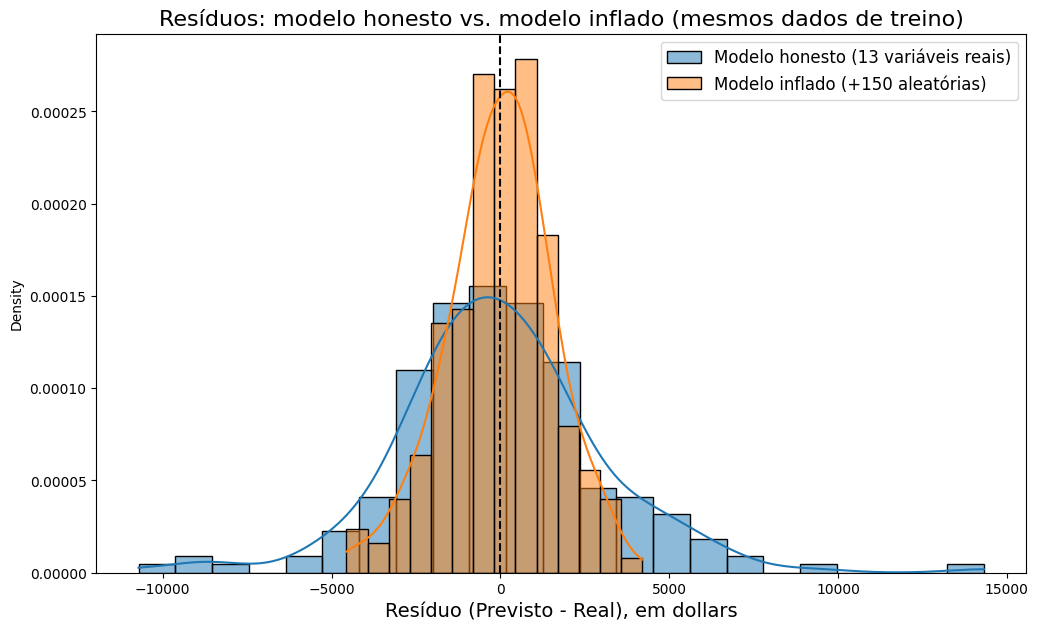

In [16]:
y_pred_honesto = lm.predict(X)
y_pred_inflado = lm_inflado.predict(X_inflado)

residuos_honesto = Y - y_pred_honesto
residuos_inflado = Y_inflado - y_pred_inflado

plt.figure(figsize=(12, 7))

sns.histplot(residuos_honesto, kde=True, stat="density", color="tab:blue",
             label="Modelo honesto (13 variáveis reais)", alpha=0.5)
sns.histplot(residuos_inflado, kde=True, stat="density", color="tab:orange",
             label=f"Modelo inflado (+{c} aleatórias)", alpha=0.5)

plt.axvline(0, color="k", linestyle="--")
plt.title("Resíduos: modelo honesto vs. modelo inflado (mesmos dados de treino)", size=16)
plt.xlabel("Resíduo (Previsto - Real), em dollars", size=14)
plt.legend(fontsize=12)
plt.show()

### A ilusão do ajuste perfeito

Olhando só para os resíduos, o modelo inflado parece muito melhor: os erros ficam bem mais concentrados perto de zero. Mas isso **não significa que esse modelo vai prever melhor o preço de um carro novo** — ele só está mais bem ajustado aos dados que já viu, inclusive ao ruído das 150 colunas aleatórias.

A única forma de saber se um modelo realmente generaliza é avaliá-lo em dados que ele **não viu** durante o treino. É exatamente isso que vamos aprender na próxima aula, com o `train_test_split`.

## Fique Conectado

- [![YouTube](https://img.icons8.com/ios-filled/40/000000/youtube-play.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/ios-filled/40/000000/linkedin.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/ios-filled/40/000000/instagram-new.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>, <a href="https://www.linkedin.com/in/hesauhugocavalcanti/" target="_blank">Hesau Hugo</a> , <a href="https://www.linkedin.com/in/joão-gabriel-santin-botelho/" target="_blank">João Gabriel</a>

## Referências:

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação da biblioteca <a href="https://seaborn.pydata.org/">Seaborn</a>
* Documentação do biblioteca <a href="https://matplotlib.org/">Matplotlib</a>
* Documentação do biblioteca <a href="https://numpy.org/devdocs/reference/index.html">Numpy</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
|  17-04-2023          | 1.0     | Hesau Hugo    | Inicial               |
| 22-04-2024       | 1.1     | Eduardo Pecora    | Estrutura Aula        |
| 18-09-2024       | 1.2     | João Gabriel      | Atualização           |